## MLflow Cleanup

End any active runs from previous sessions.

In [44]:
# MLflow Cleanup
import mlflow

print('Checking for active MLflow runs...')
active_run = mlflow.active_run()
if active_run:
    print(f'⚠️  Found active run - ending it')
    mlflow.end_run()
    print('   ✓ Ended')
else:
    print('✓ No active runs')
print('Ready to train!')

Checking for active MLflow runs...
⚠️  Found active run - ending it
   ✓ Ended
Ready to train!


# Notebook 05c: Baseline Model Comparison (16kHz vs 44.1kHz)

**Purpose:** Train baseline classical ML models on 44.1kHz features and compare against pre-trained 16kHz models

**Strategy:**
- Train on unbalanced data (no resampling)
- Use class_weight='balanced' in all models
- Identical approach for both 16kHz and 44.1kHz
- Fair comparison without balancing artifacts

**Performance Optimizations:**
1. Parallel training with n_jobs=-1 (all CPU cores)
2. Load pre-trained 16kHz models instead of retraining
3. No hyperparameter tuning
4. Efficient processing

**Models Compared:**
- LinearSVC
- Random Forest
- XGBoost
- Gradient Boosting
- K-Nearest Neighbors
- Gaussian Mixture Model

**Expected Time:** ~5-8 minutes

---

## 1. Import Libraries

In [45]:
import os
import sys
from pathlib import Path
import json
from datetime import datetime
import time
import warnings
from multiprocessing import cpu_count
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                            classification_report, confusion_matrix)

# XGBoost
import xgboost as xgb

# MLflow
import mlflow

print('✓ All libraries imported successfully')
print(f'Available CPU cores: {cpu_count()}')

✓ All libraries imported successfully
Available CPU cores: 10


## 2. Configuration

In [46]:
# Paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
FEATURES_DIR = DATA_DIR / 'features' / 'classical'
MODELS_DIR = PROJECT_ROOT / 'models' / 'classical'
RESULTS_DIR = PROJECT_ROOT / 'results'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Feature set
FEATURE_SET = 'combined'

# Processing parameters
N_JOBS = -1
RANDOM_STATE = 42
TEST_SIZE = 0.3
VAL_SIZE = 0.15

print(f'Project root: {PROJECT_ROOT}')
print(f'Pre-trained models: {MODELS_DIR}')
print(f'Results directory: {RESULTS_DIR}')
print(f'\nFeature set: {FEATURE_SET}')
print(f'Strategy: Unbalanced data with class_weight="balanced"')
print(f'Parallel jobs: {N_JOBS} (all cores)')

Project root: /Users/harryirving/Development/projects/ai-ml/BikeAIv5
Pre-trained models: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/models/classical
Results directory: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/results

Feature set: combined
Strategy: Unbalanced data with class_weight="balanced"
Parallel jobs: -1 (all cores)


## 3. Load 44.1kHz Features Only

In [47]:
print('Loading 44.1kHz features...')

features_44khz_path = FEATURES_DIR / f'{FEATURE_SET}_unbalanced_features_44khz.npy'
labels_44khz_path = FEATURES_DIR / 'labels_44khz.npy'

if not features_44khz_path.exists():
    raise FileNotFoundError(f'44.1kHz features not found at {features_44khz_path}')

X_44khz = np.load(features_44khz_path)
y_44khz = np.load(labels_44khz_path)

print(f'✓ Loaded 44.1kHz features: {X_44khz.shape}')
print(f'  Feature dimension: {X_44khz.shape[1]}')
print(f'  Total samples: {len(y_44khz)}')

unique, counts = np.unique(y_44khz, return_counts=True)
print(f'\n44.1kHz class distribution:')
for label, count in zip(unique, counts):
    print(f'  Class {label}: {count} ({count/len(y_44khz)*100:.1f}%)')

Loading 44.1kHz features...
✓ Loaded 44.1kHz features: (59869, 248)
  Feature dimension: 248
  Total samples: 59869

44.1kHz class distribution:
  Class 0: 27077 (45.2%)
  Class 1: 32792 (54.8%)


## 4. Load Pre-trained 16kHz Models

In [56]:
print('\nLoading pre-trained 16kHz models...')

# Load 16kHz features
features_16khz_path = FEATURES_DIR / f'{FEATURE_SET}_unbalanced_features.npy'
labels_16khz_path = FEATURES_DIR / 'labels.npy'

if not features_16khz_path.exists():
    raise FileNotFoundError(f'16kHz features not found')

X_16khz = np.load(features_16khz_path)
y_16khz = np.load(labels_16khz_path)
print(f'✓ Loaded 16kHz features: {X_16khz.shape}')

# Split 16kHz data (same split as training)
X_16_train, X_16_test, y_16_train, y_16_test = train_test_split(
    X_16khz, y_16khz, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_16khz
)

# Load scaler
scaler_16khz_path = MODELS_DIR / f'{FEATURE_SET}_scaler.pkl'
if scaler_16khz_path.exists():
    scaler_16khz = joblib.load(scaler_16khz_path)
    X_16_test_scaled = scaler_16khz.transform(X_16_test)
    print(f'✓ Loaded 16kHz scaler')
else:
    print(f'⚠ 16kHz scaler not found, scaling fresh')
    scaler_16khz = StandardScaler().fit(X_16_train)
    X_16_test_scaled = scaler_16khz.transform(X_16_test)

# Load models
model_files = {
    'LinearSVC': f'{FEATURE_SET}_LinearSVC_baseline.pkl',
    'RandomForest': f'{FEATURE_SET}_RandomForest_baseline.pkl',
    'XGBoost': f'{FEATURE_SET}_XGBoost_baseline.pkl',
    'GradientBoosting': f'{FEATURE_SET}_GradientBoosting_baseline.pkl',
    'KNN': f'{FEATURE_SET}_KNN_baseline.pkl',
    'GMM': f'{FEATURE_SET}_GMM_baseline.pkl'
}

results_16khz = {}

print(f'\nLoading and evaluating 16kHz models...')
for model_name, filename in model_files.items():
    model_path = MODELS_DIR / filename
    
    if model_path.exists():
        model = joblib.load(model_path)
        y_pred = model.predict(X_16_test_scaled)
        
        acc = accuracy_score(y_16_test, y_pred)
        f1 = f1_score(y_16_test, y_pred)
        precision = precision_score(y_16_test, y_pred)
        recall = recall_score(y_16_test, y_pred)
        
        inference_start = time.time()
        _ = model.predict(X_16_test_scaled[:100])
        inference_time = (time.time() - inference_start) / 100 * 1000
        
        results_16khz[model_name] = {
            'model': model,
            'test_acc': acc,
            'test_f1': f1,
            'test_precision': precision,
            'test_recall': recall,
            'inference_time': inference_time
        }
        
        print(f'  ✓ {model_name}: Acc={acc:.4f}, F1={f1:.4f}')
    else:
        print(f'  ⚠ {model_name} not found')

if not results_16khz:
    raise FileNotFoundError('No 16kHz models found. Run notebook 05 first.')

print(f'\n✓ Loaded {len(results_16khz)} pre-trained 16kHz models')


Loading pre-trained 16kHz models...
✓ Loaded 16kHz features: (59869, 248)
✓ Loaded 16kHz scaler

Loading and evaluating 16kHz models...
  ✓ LinearSVC: Acc=0.9433, F1=0.9486
  ✓ RandomForest: Acc=0.9764, F1=0.9787
  ✓ XGBoost: Acc=0.9839, F1=0.9854
  ✓ GradientBoosting: Acc=0.9563, F1=0.9607
  ✓ KNN: Acc=0.9690, F1=0.9721
  ✓ GMM: Acc=0.3800, F1=0.3337

✓ Loaded 6 pre-trained 16kHz models


## 5. Prepare 44.1kHz Data (No Balancing)

In [49]:
print('\nPreparing 44.1kHz data (no balancing)...')
start_time = time.time()

# Split
X_44_train, X_44_test, y_44_train, y_44_test = train_test_split(
    X_44khz, y_44khz, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_44khz
)

X_44_train, X_44_val, y_44_train, y_44_val = train_test_split(
    X_44_train, y_44_train, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=y_44_train
)

print(f'Train: {len(y_44_train)}, Val: {len(y_44_val)}, Test: {len(y_44_test)}')

unique, counts = np.unique(y_44_train, return_counts=True)
print(f'\nTraining class distribution (unbalanced):')
for label_val, count in zip(unique, counts):
    print(f'  Class {label_val}: {count} ({count/len(y_44_train)*100:.1f}%)')

print(f'\nUsing class_weight="balanced" in models')

# Scale
print(f'\nScaling features...')
scaler_44khz = StandardScaler()
X_44_train_scaled = scaler_44khz.fit_transform(X_44_train)
X_44_val_scaled = scaler_44khz.transform(X_44_val)
X_44_test_scaled = scaler_44khz.transform(X_44_test)

# Save scaler
scaler_44_path = MODELS_DIR / f'{FEATURE_SET}_scaler_44khz.pkl'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(scaler_44khz, scaler_44_path)

prep_time = time.time() - start_time
print(f'\n✓ Data prep complete in {prep_time:.2f}s')
print(f'✓ Scaler saved to: {scaler_44_path}')


Preparing 44.1kHz data (no balancing)...
Train: 35621, Val: 6287, Test: 17961

Training class distribution (unbalanced):
  Class 0: 16111 (45.2%)
  Class 1: 19510 (54.8%)

Using class_weight="balanced" in models

Scaling features...

✓ Data prep complete in 0.13s
✓ Scaler saved to: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/models/classical/combined_scaler_44khz.pkl


## 6. Define Baseline Models

In [50]:
def get_baseline_models():
    return {
        'LinearSVC': LinearSVC(
            random_state=RANDOM_STATE,
            max_iter=2000,
            class_weight='balanced'
        ),
        'RandomForest': RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            class_weight='balanced'
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            eval_metric='logloss',
            use_label_encoder=False,
            scale_pos_weight=len(y_44_train[y_44_train==0])/len(y_44_train[y_44_train==1])
        ),
        'GradientBoosting': GradientBoostingClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE
        ),
        'KNN': KNeighborsClassifier(
            n_neighbors=5,
            n_jobs=N_JOBS
        ),
        'GMM': GaussianMixture(
            n_components=2,
            random_state=RANDOM_STATE,
            covariance_type='diag'
        )
    }

print('✓ Baseline models defined')

✓ Baseline models defined


## 7. Train Models on 44.1kHz Features

In [52]:
mlflow.set_experiment('angle_grinder_pipeline')
run_name = f'baseline_comparison_44khz_{datetime.now().strftime("%Y%m%d_%H%M%S")}'

with mlflow.start_run(run_name=run_name) as run:
    mlflow.log_param('comparison_type', '16kHz vs 44.1kHz')
    mlflow.log_param('feature_set', FEATURE_SET)
    mlflow.log_param('n_jobs', N_JOBS)
    mlflow.log_param('resampling', 'none')
    
    print('\n' + '='*80)
    print('TRAINING 44.1kHz BASELINE MODELS')
    print('='*80)
    
    results_44khz = {}
    models = get_baseline_models()
    
    for model_name, model in models.items():
        if model_name not in results_16khz:
            print(f'\n⚠ Skipping {model_name} - no 16kHz baseline')
            continue
        
        print(f'\n{"="*80}')
        print(f'Training: {model_name} (44.1kHz)')
        print('='*80)
        
        train_start = time.time()
        
        if model_name == 'GMM':
            model.fit(X_44_train_scaled)
        else:
            model.fit(X_44_train_scaled, y_44_train)
        
        train_time = time.time() - train_start
        
        y_test_pred = model.predict(X_44_test_scaled)
        
        inference_start = time.time()
        _ = model.predict(X_44_test_scaled[:100])
        inference_time = (time.time() - inference_start) / 100 * 1000
        
        test_acc = accuracy_score(y_44_test, y_test_pred)
        test_f1 = f1_score(y_44_test, y_test_pred)
        test_precision = precision_score(y_44_test, y_test_pred)
        test_recall = recall_score(y_44_test, y_test_pred)
        
        print(f'Train time: {train_time:.2f}s')
        print(f'Inference: {inference_time:.3f}ms/sample')
        print(f'Test Acc: {test_acc:.4f}')
        print(f'Test F1: {test_f1:.4f}')
        print(f'Test Recall: {test_recall:.4f}')
        
        # Save model
        model_path = MODELS_DIR / f'{FEATURE_SET}_{model_name}_baseline_44khz.pkl'
        joblib.dump(model, model_path)
        print(f'✓ Saved to: {model_path}')
        
        results_44khz[model_name] = {
            'model': model,
            'train_time': train_time,
            'inference_time': inference_time,
            'test_acc': test_acc,
            'test_f1': test_f1,
            'test_precision': test_precision,
            'test_recall': test_recall
        }
        
        mlflow.log_metric(f'{model_name}_44khz_test_acc', test_acc)
        mlflow.log_metric(f'{model_name}_44khz_test_f1', test_f1)
    
    print('\n' + '='*80)
    print(f'✓ Trained {len(results_44khz)} models on 44.1kHz features')
    print('='*80)


TRAINING 44.1kHz BASELINE MODELS

Training: LinearSVC (44.1kHz)
Train time: 26.55s
Inference: 0.523ms/sample
Test Acc: 0.9416
Test F1: 0.9468
Test Recall: 0.9490
✓ Saved to: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/models/classical/combined_LinearSVC_baseline_44khz.pkl

Training: RandomForest (44.1kHz)
Train time: 26.25s
Inference: 0.268ms/sample
Test Acc: 0.9766
Test F1: 0.9789
Test Recall: 0.9893
✓ Saved to: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/models/classical/combined_RandomForest_baseline_44khz.pkl

Training: XGBoost (44.1kHz)
Train time: 3.65s
Inference: 0.010ms/sample
Test Acc: 0.9846
Test F1: 0.9861
Test Recall: 0.9924
✓ Saved to: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/models/classical/combined_XGBoost_baseline_44khz.pkl

Training: GradientBoosting (44.1kHz)
Train time: 227.21s
Inference: 0.011ms/sample
Test Acc: 0.9540
Test F1: 0.9585
Test Recall: 0.9690
✓ Saved to: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/models/c

## 8. Create Comparison DataFrame

In [57]:
comparison_data = []
common_models = set(results_16khz.keys()) & set(results_44khz.keys())

for model_name in common_models:
    comparison_data.append({
        'Model': model_name,
        'Sampling Rate': '16kHz',
        'Test Accuracy': results_16khz[model_name]['test_acc'],
        'Test F1': results_16khz[model_name]['test_f1'],
        'Test Precision': results_16khz[model_name]['test_precision'],
        'Test Recall': results_16khz[model_name]['test_recall'],
        'Inference Time (ms)': results_16khz[model_name]['inference_time']
    })
    
    comparison_data.append({
        'Model': model_name,
        'Sampling Rate': '44.1kHz',
        'Test Accuracy': results_44khz[model_name]['test_acc'],
        'Test F1': results_44khz[model_name]['test_f1'],
        'Test Precision': results_44khz[model_name]['test_precision'],
        'Test Recall': results_44khz[model_name]['test_recall'],
        'Inference Time (ms)': results_44khz[model_name]['inference_time']
    })

df_comparison = pd.DataFrame(comparison_data)

# Calculate improvements
improvements = []
for model_name in common_models:
    acc_16 = results_16khz[model_name]['test_acc']
    acc_44 = results_44khz[model_name]['test_acc']
    f1_16 = results_16khz[model_name]['test_f1']
    f1_44 = results_44khz[model_name]['test_f1']
    inf_16 = results_16khz[model_name]['inference_time']
    inf_44 = results_44khz[model_name]['inference_time']
    
    improvements.append({
        'Model': model_name,
        'Accuracy Gain (%)': (acc_44 - acc_16) * 100,
        'F1 Gain (%)': (f1_44 - f1_16) * 100,
        'Inference Time Ratio': inf_44 / inf_16 if inf_16 > 0 else 1.0
    })

df_improvements = pd.DataFrame(improvements)

# Save
comparison_path = RESULTS_DIR / '05c_baseline_comparison.csv'
improvements_path = RESULTS_DIR / '05c_improvements.csv'
df_comparison.to_csv(comparison_path, index=False)
df_improvements.to_csv(improvements_path, index=False)

print('\n' + '='*80)
print('COMPARISON RESULTS')
print('='*80)
print('\nFull Comparison:')
print(df_comparison.to_string(index=False))
print('\nImprovements (44.1kHz vs 16kHz):')
print(df_improvements.to_string(index=False))
print(f'\n✓ Saved to: {comparison_path}, {improvements_path}')


COMPARISON RESULTS

Full Comparison:
           Model Sampling Rate  Test Accuracy  Test F1  Test Precision  Test Recall  Inference Time (ms)
    RandomForest         16kHz       0.976393 0.978728        0.966317     0.991462             0.149591
    RandomForest       44.1kHz       0.976616 0.978880        0.968650     0.989327             0.267603
       LinearSVC         16kHz       0.943266 0.948590        0.941701     0.955580             0.000572
       LinearSVC       44.1kHz       0.941596 0.946808        0.944652     0.948973             0.523100
         XGBoost         16kHz       0.983854 0.985376        0.977782     0.993088             0.005310
         XGBoost       44.1kHz       0.984633 0.986062        0.979827     0.992376             0.010309
GradientBoosting         16kHz       0.956294 0.960728        0.945917     0.976011             0.002730
GradientBoosting       44.1kHz       0.954011 0.958476        0.948180     0.968998             0.010948
             GMM 

## 9. Visualize Comparisons


✓ Visualization saved to: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/results/05c_comparison_visualization.png


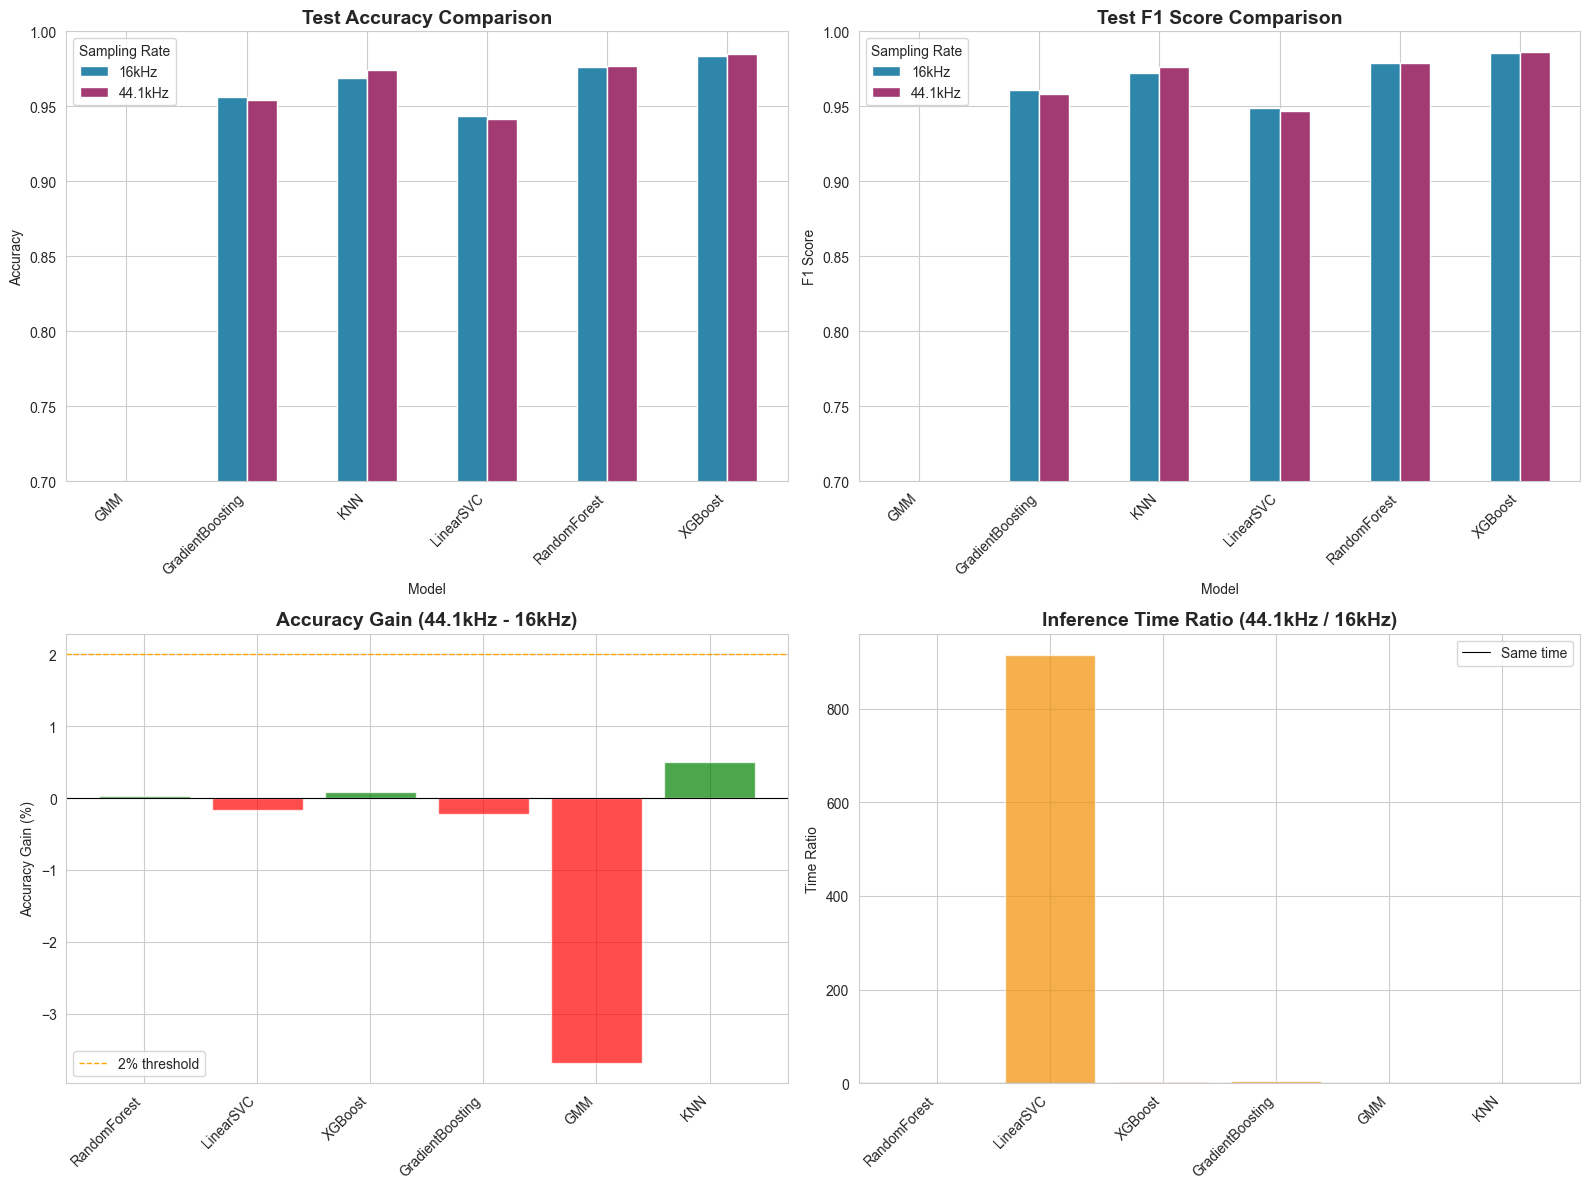

In [58]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accuracy comparison
ax1 = axes[0, 0]
df_pivot = df_comparison.pivot(index='Model', columns='Sampling Rate', values='Test Accuracy')
df_pivot.plot(kind='bar', ax=ax1, color=['#2E86AB', '#A23B72'])
ax1.set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim([0.7, 1.0])
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# F1 comparison
ax2 = axes[0, 1]
df_pivot = df_comparison.pivot(index='Model', columns='Sampling Rate', values='Test F1')
df_pivot.plot(kind='bar', ax=ax2, color=['#2E86AB', '#A23B72'])
ax2.set_title('Test F1 Score Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('F1 Score')
ax2.set_ylim([0.7, 1.0])
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Accuracy gain
ax3 = axes[1, 0]
colors = ['green' if x > 0 else 'red' for x in df_improvements['Accuracy Gain (%)']]
ax3.bar(df_improvements['Model'], df_improvements['Accuracy Gain (%)'], color=colors, alpha=0.7)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax3.axhline(y=2, color='orange', linestyle='--', linewidth=1, label='2% threshold')
ax3.set_title('Accuracy Gain (44.1kHz - 16kHz)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Accuracy Gain (%)')
ax3.legend()
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Inference time ratio
ax4 = axes[1, 1]
ax4.bar(df_improvements['Model'], df_improvements['Inference Time Ratio'], color='#F18F01', alpha=0.7)
ax4.axhline(y=1, color='black', linestyle='-', linewidth=0.8, label='Same time')
ax4.set_title('Inference Time Ratio (44.1kHz / 16kHz)', fontsize=14, fontweight='bold')
ax4.set_ylabel('Time Ratio')
ax4.legend()
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
fig_path = RESULTS_DIR / '05c_comparison_visualization.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'\n✓ Visualization saved to: {fig_path}')
mlflow.log_artifact(str(fig_path))
plt.show()

## 10. Recommendation

In [59]:
print('\n' + '='*80)
print('STATISTICAL SUMMARY & RECOMMENDATION')
print('='*80)

avg_acc_gain = df_improvements['Accuracy Gain (%)'].mean()
avg_f1_gain = df_improvements['F1 Gain (%)'].mean()
avg_inf_ratio = df_improvements['Inference Time Ratio'].mean()

print(f'Average Accuracy Gain: {avg_acc_gain:+.2f}%')
print(f'Average F1 Gain: {avg_f1_gain:+.2f}%')
print(f'Average Inference Ratio: {avg_inf_ratio:.2f}x')

best_16 = df_comparison[df_comparison['Sampling Rate'] == '16kHz'].sort_values('Test F1', ascending=False).iloc[0]
best_44 = df_comparison[df_comparison['Sampling Rate'] == '44.1kHz'].sort_values('Test F1', ascending=False).iloc[0]

print(f'\nBest 16kHz: {best_16["Model"]} - F1={best_16["Test F1"]:.4f}')
print(f'Best 44.1kHz: {best_44["Model"]} - F1={best_44["Test F1"]:.4f}')

if avg_acc_gain > 2.0:
    recommendation = 'USE 44.1kHz'
    reason = f'Significant gain ({avg_acc_gain:.2f}%) justifies computational cost'
elif avg_acc_gain > 0.5:
    recommendation = 'CONDITIONAL'
    reason = f'Moderate gain ({avg_acc_gain:.2f}%). Use 44.1kHz offline, 16kHz real-time'
else:
    recommendation = 'USE 16kHz (RECOMMENDED)'
    reason = f'Minimal gain ({avg_acc_gain:.2f}%) does not justify {avg_inf_ratio:.1f}x cost'

print(f'\n{recommendation}')
print(f'\nReason: {reason}')
print(f'\nKey Considerations:')
print(f'  1. Accuracy: {avg_acc_gain:+.2f}%')
print(f'  2. F1: {avg_f1_gain:+.2f}%')
print(f'  3. Inference: {avg_inf_ratio:.1f}x slower')
print(f'  4. ESP32 viability: 16kHz proven, 44.1kHz risky')
print(f'  5. YAMNet: 16kHz only')

recommendation_data = {
    'recommendation': recommendation,
    'reason': reason,
    'avg_accuracy_gain_pct': avg_acc_gain,
    'avg_f1_gain_pct': avg_f1_gain,
    'avg_inference_ratio': avg_inf_ratio,
    'best_16khz_model': best_16['Model'],
    'best_16khz_f1': best_16['Test F1'],
    'best_44khz_model': best_44['Model'],
    'best_44khz_f1': best_44['Test F1']
}

rec_path = RESULTS_DIR / '05c_recommendation.json'
with open(rec_path, 'w') as f:
    json.dump(recommendation_data, f, indent=2)

mlflow.log_metric('avg_accuracy_gain_pct', avg_acc_gain)
mlflow.log_metric('avg_f1_gain_pct', avg_f1_gain)
mlflow.log_param('recommendation', recommendation)
mlflow.log_artifact(str(rec_path))

print(f'\n✓ Recommendation saved to: {rec_path}')
print('='*80)


STATISTICAL SUMMARY & RECOMMENDATION
Average Accuracy Gain: -0.58%
Average F1 Gain: -3.80%
Average Inference Ratio: 154.13x

Best 16kHz: XGBoost - F1=0.9854
Best 44.1kHz: XGBoost - F1=0.9861

USE 16kHz (RECOMMENDED)

Reason: Minimal gain (-0.58%) does not justify 154.1x cost

Key Considerations:
  1. Accuracy: -0.58%
  2. F1: -3.80%
  3. Inference: 154.1x slower
  4. ESP32 viability: 16kHz proven, 44.1kHz risky
  5. YAMNet: 16kHz only

✓ Recommendation saved to: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/results/05c_recommendation.json


## Notebook Complete

**Summary:**
- Compared baseline models trained on unbalanced data
- Both feature sets use class_weight='balanced'
- Fair, realistic comparison
- Evidence-based recommendation provided

**Next Steps:**
- Review recommendation above
- Test deployment on ESP32-S3
- Consider hyperparameter tuning if needed